In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(
    "../data/asset_prioritization_dataset.csv"
)

df.head()

,Asset_ID,Asset_Type,Installation_Year,Last_Maintenance_Date,Total_Maintenance_Cost,Condition_Score,Failure_Impact_Score,Failure_History_Count,Operating_Hours,Environmental_Stress_Index,System_Importance_Score,Failure_Probability,Priority_Score,Budget_Constraint_Flag,Scheduled_Disposal_Year,RUL
0,A0001,Switchgear,1991,2021-12-08,45406.15,9.22,4,5,81703,0.99,0.64,0.52,44.48,1,2025,5.90
1,A0002,Recloser,2015,2019-10-19,33701.25,9.58,19,0,42445,0.73,0.59,0.83,66.85,1,2029,10.26
2,A0003,Cable,1983,2022-02-06,28241.81,3.94,91,6,48636,0.36,0.90,0.82,62.99,0,2034,3.08
3,A0004,Recloser,1984,2022-04-30,5993.98,4.19,45,6,74927,0.70,0.65,0.95,1.78,0,2025,0.73
4,A0005,Recloser,1987,2020-09-05,22629.25,5.55,43,9,79194,0.73,0.35,0.69,54.12,0,2034,1.89


In [3]:
print(df.info())

print(df.shape)

print(df.columns)

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Asset_ID                    1000 non-null   str    
 1   Asset_Type                  1000 non-null   str    
 2   Installation_Year           1000 non-null   int64  
 3   Last_Maintenance_Date       1000 non-null   str    
 4   Total_Maintenance_Cost      1000 non-null   float64
 5   Condition_Score             1000 non-null   float64
 6   Failure_Impact_Score        1000 non-null   int64  
 7   Failure_History_Count       1000 non-null   int64  
 8   Operating_Hours             1000 non-null   int64  
 9   Environmental_Stress_Index  1000 non-null   float64
 10  System_Importance_Score     1000 non-null   float64
 11  Failure_Probability         1000 non-null   float64
 12  Priority_Score              1000 non-null   float64
 13  Budget_Constraint_Flag      1000 non-null   i

In [4]:
df.drop(
    columns=['Asset_ID'],
    inplace=True
)

In [5]:
df["Asset_Type"] = df ["Asset_Type"].astype(str).str.strip().str.upper()
df["Asset_Type"].unique()

<ArrowStringArray>
['SWITCHGEAR', 'RECLOSER', 'CABLE', 'CIRCUIT BREAKER', 'TRANSFORMER']
Length: 5, dtype: str

In [6]:
df["Last_Maintenance_Date"] = pd.to_datetime(
    df["Last_Maintenance_Date"]
)

current_date = pd.Timestamp.today()

df["Days_Since_Maintenance"] = (
    current_date - df["Last_Maintenance_Date"]
).dt.days

df.drop(columns=["Last_Maintenance_Date"], inplace=True)


In [7]:
df["Asset_Age"] = 2025 - df["Installation_Year"]

df.drop(columns=["Installation_Year"], inplace=True)

In [8]:
label_encoder = LabelEncoder()

df["Asset_Type"] = label_encoder.fit_transform(
    df["Asset_Type"]
)

In [9]:
df.drop(columns=[
    "Priority_Score",
    "Scheduled_Disposal_Year",
    "Asset_Age"
], inplace=True)


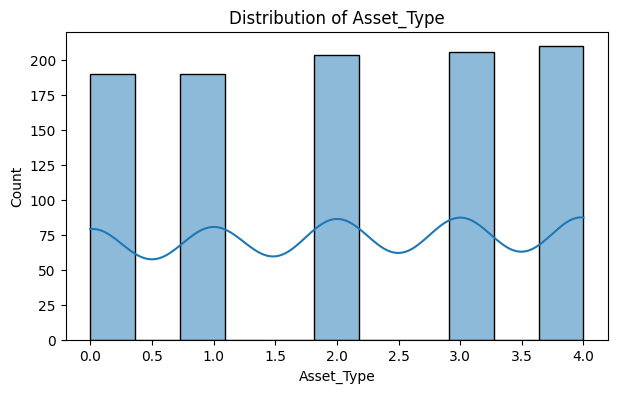

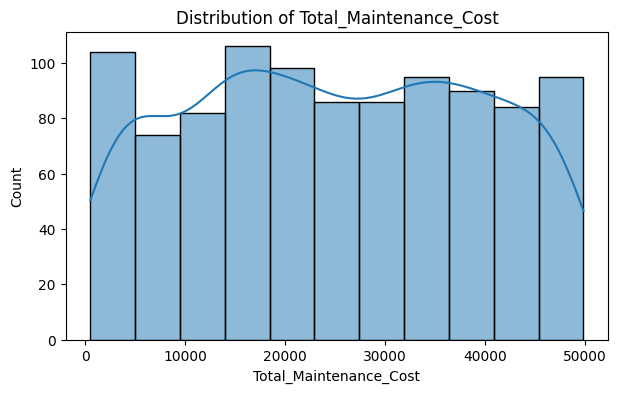

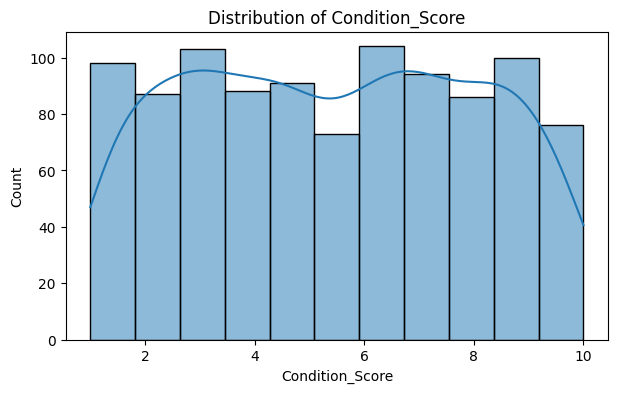

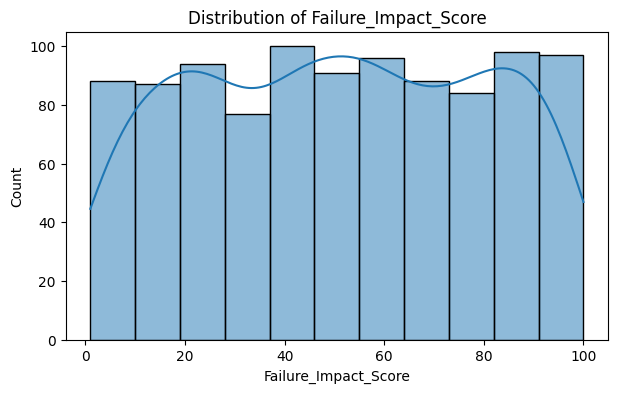

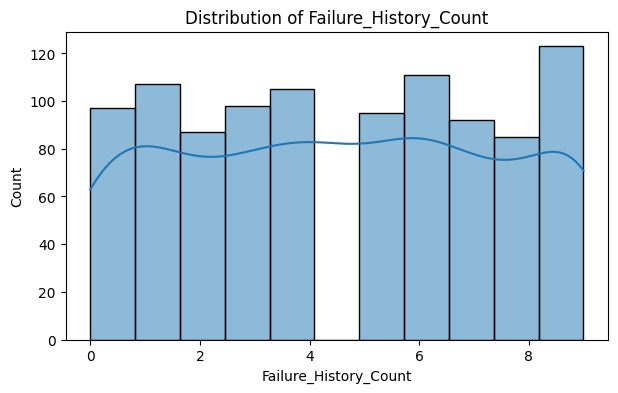

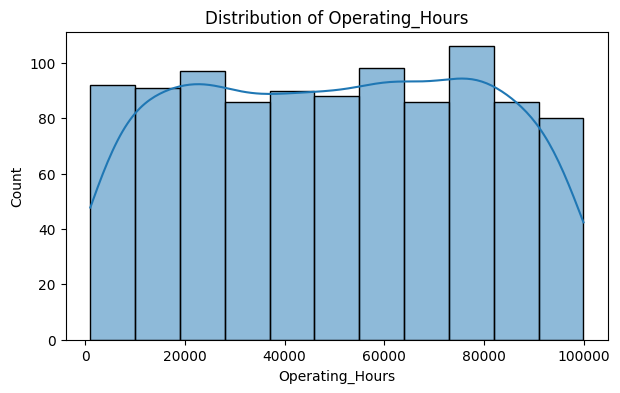

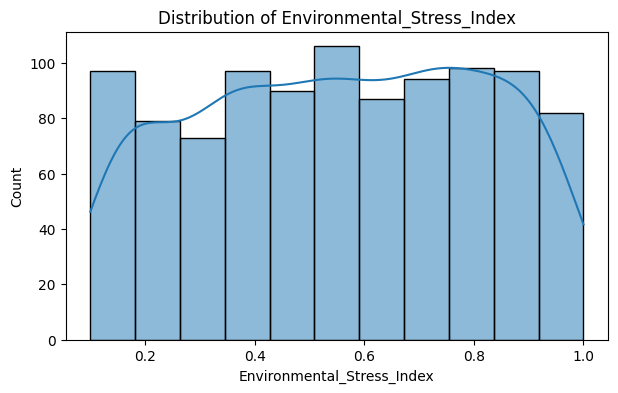

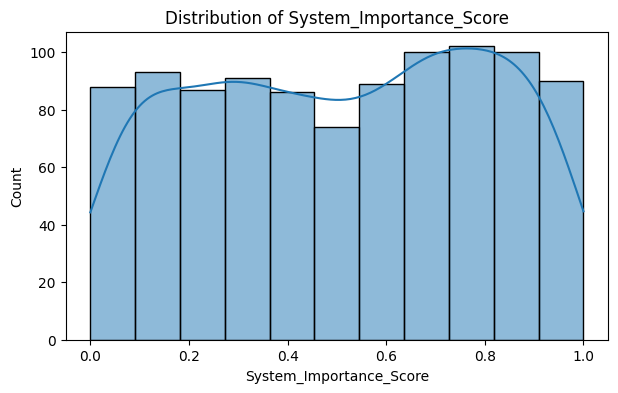

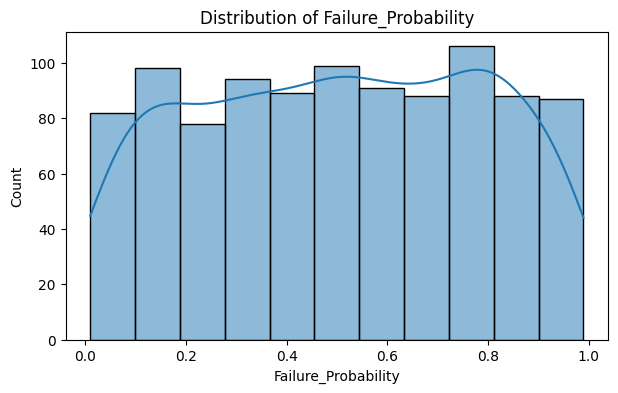

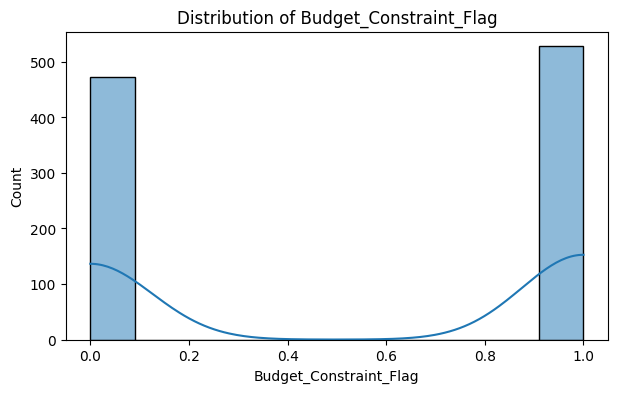

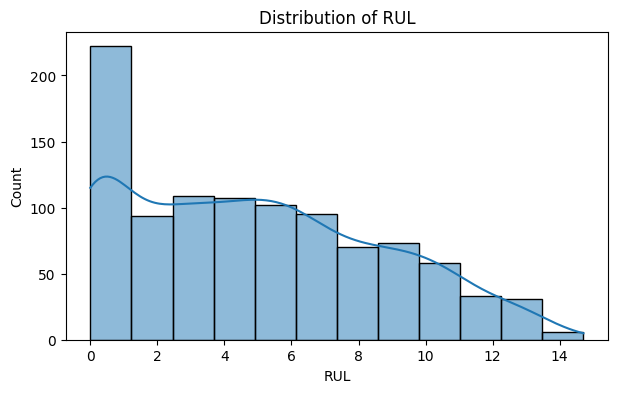

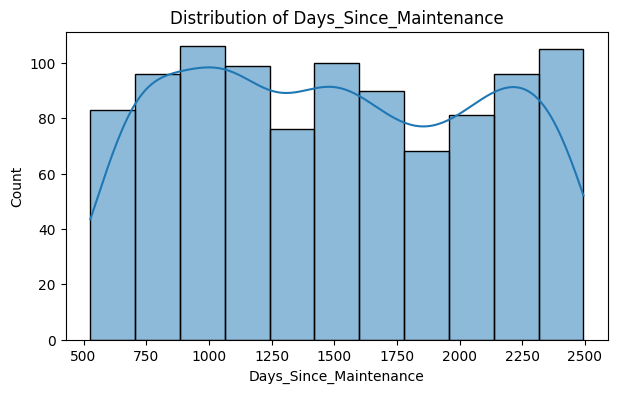

In [10]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.show()

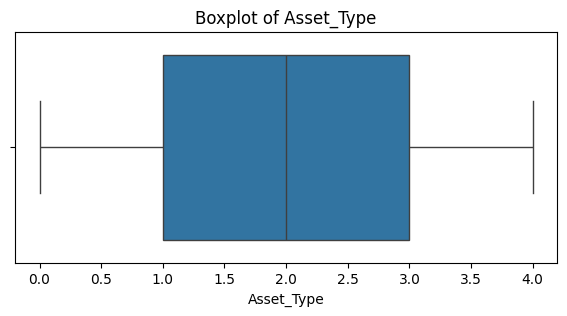

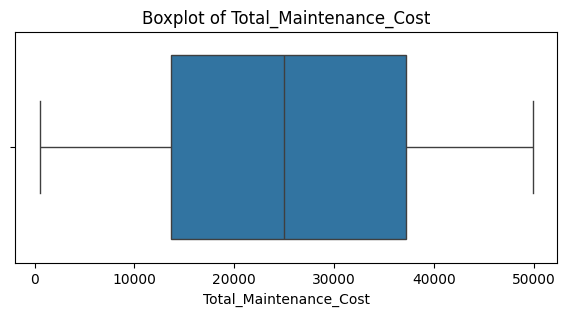

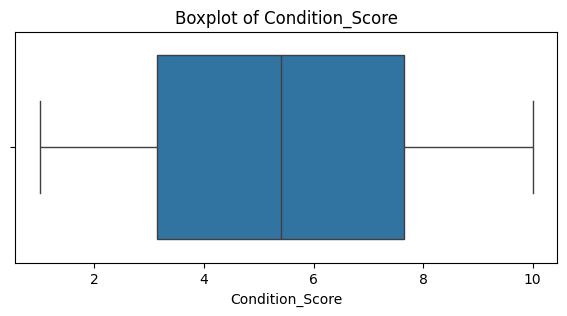

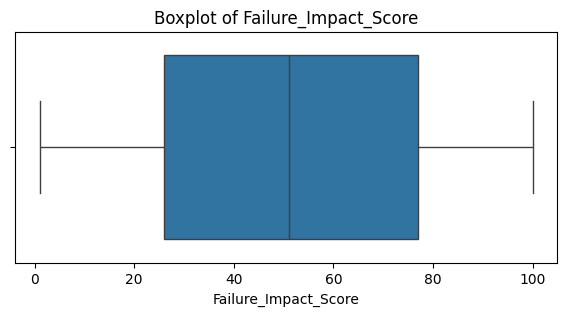

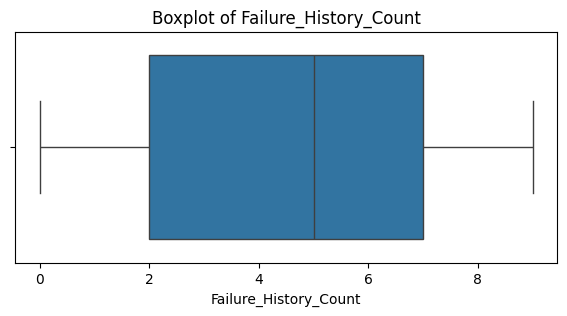

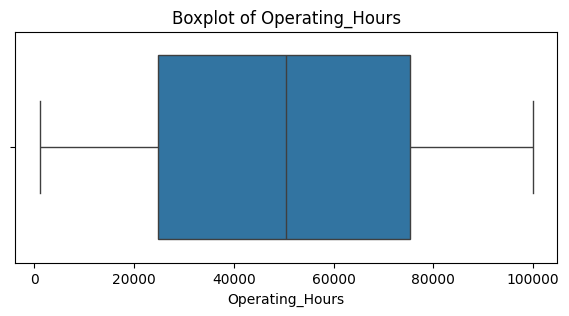

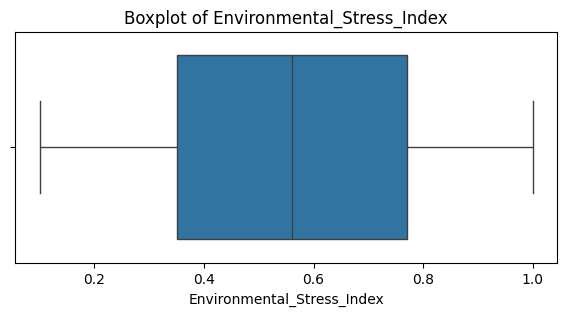

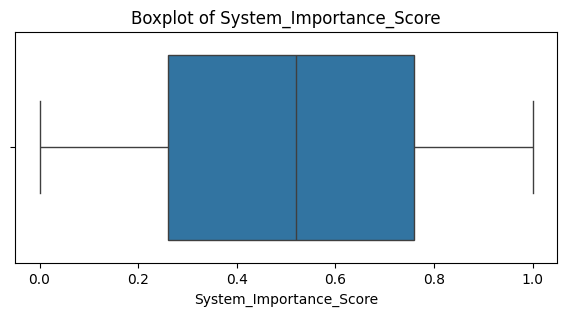

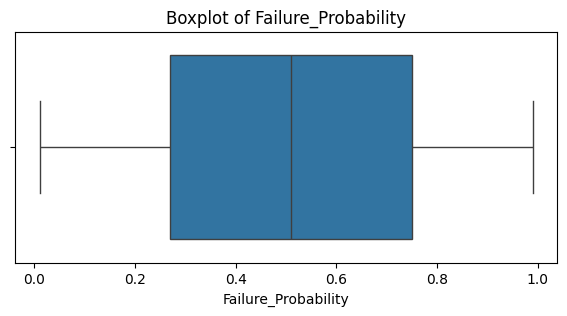

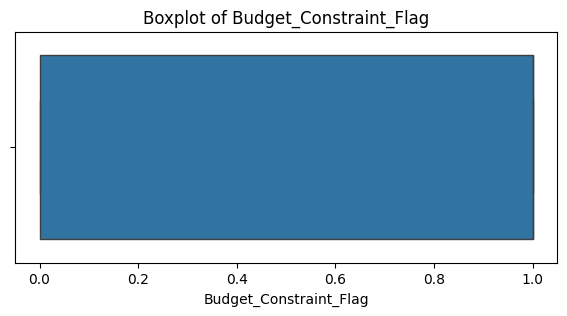

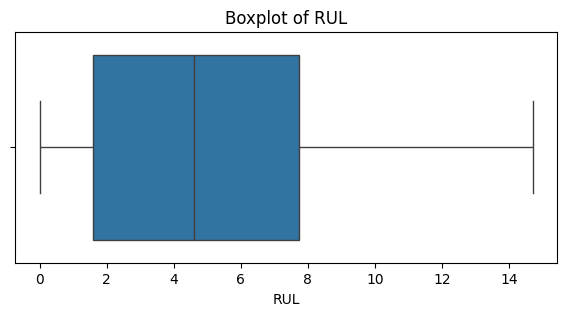

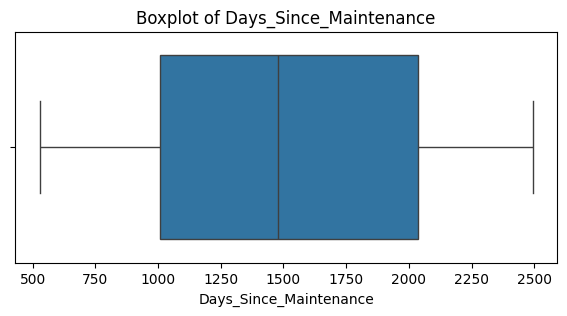

In [11]:
for column in numerical_columns:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

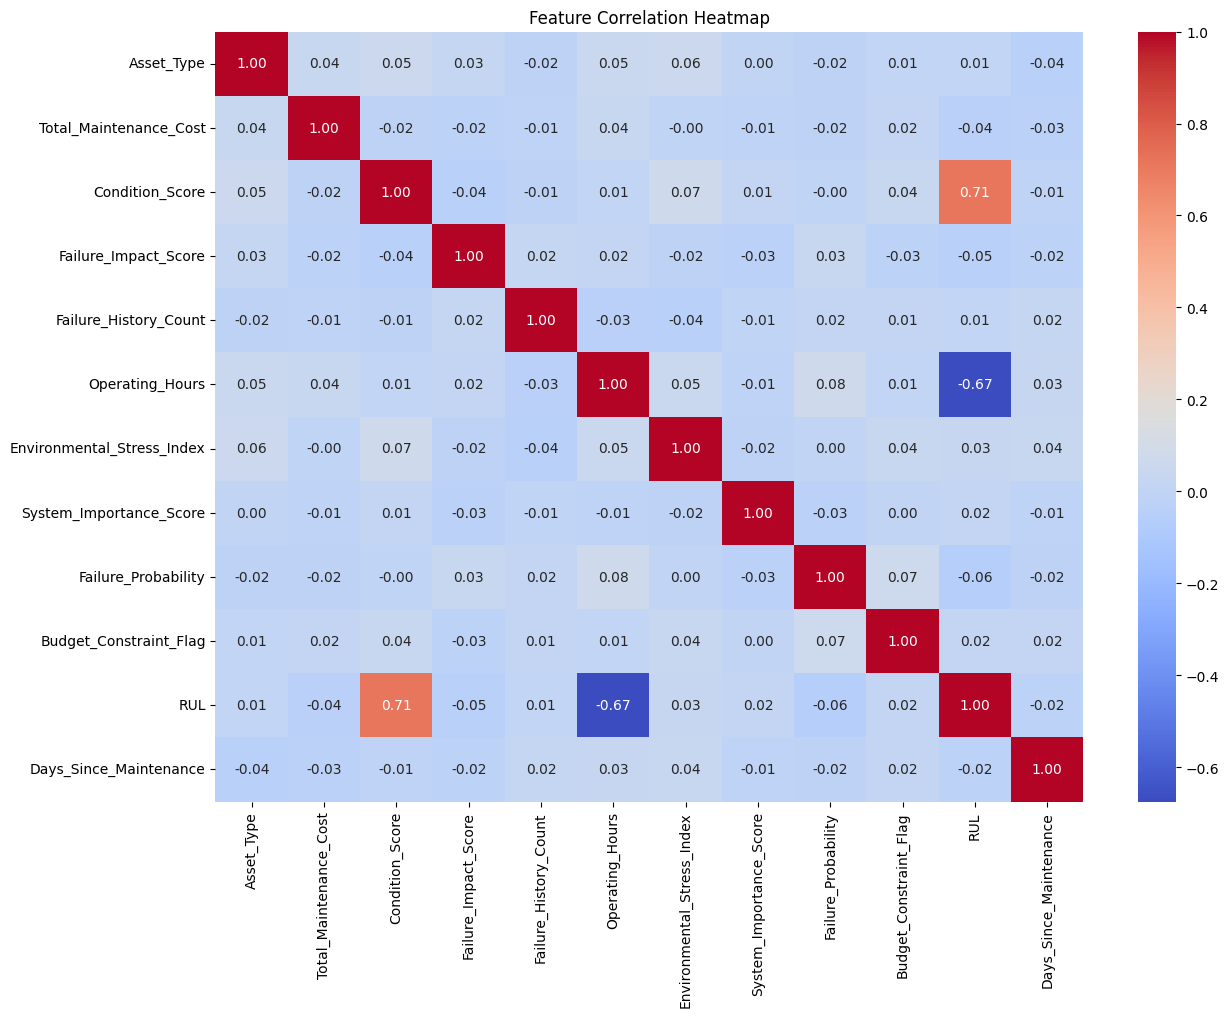

In [12]:
plt.figure(figsize=(14,10))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

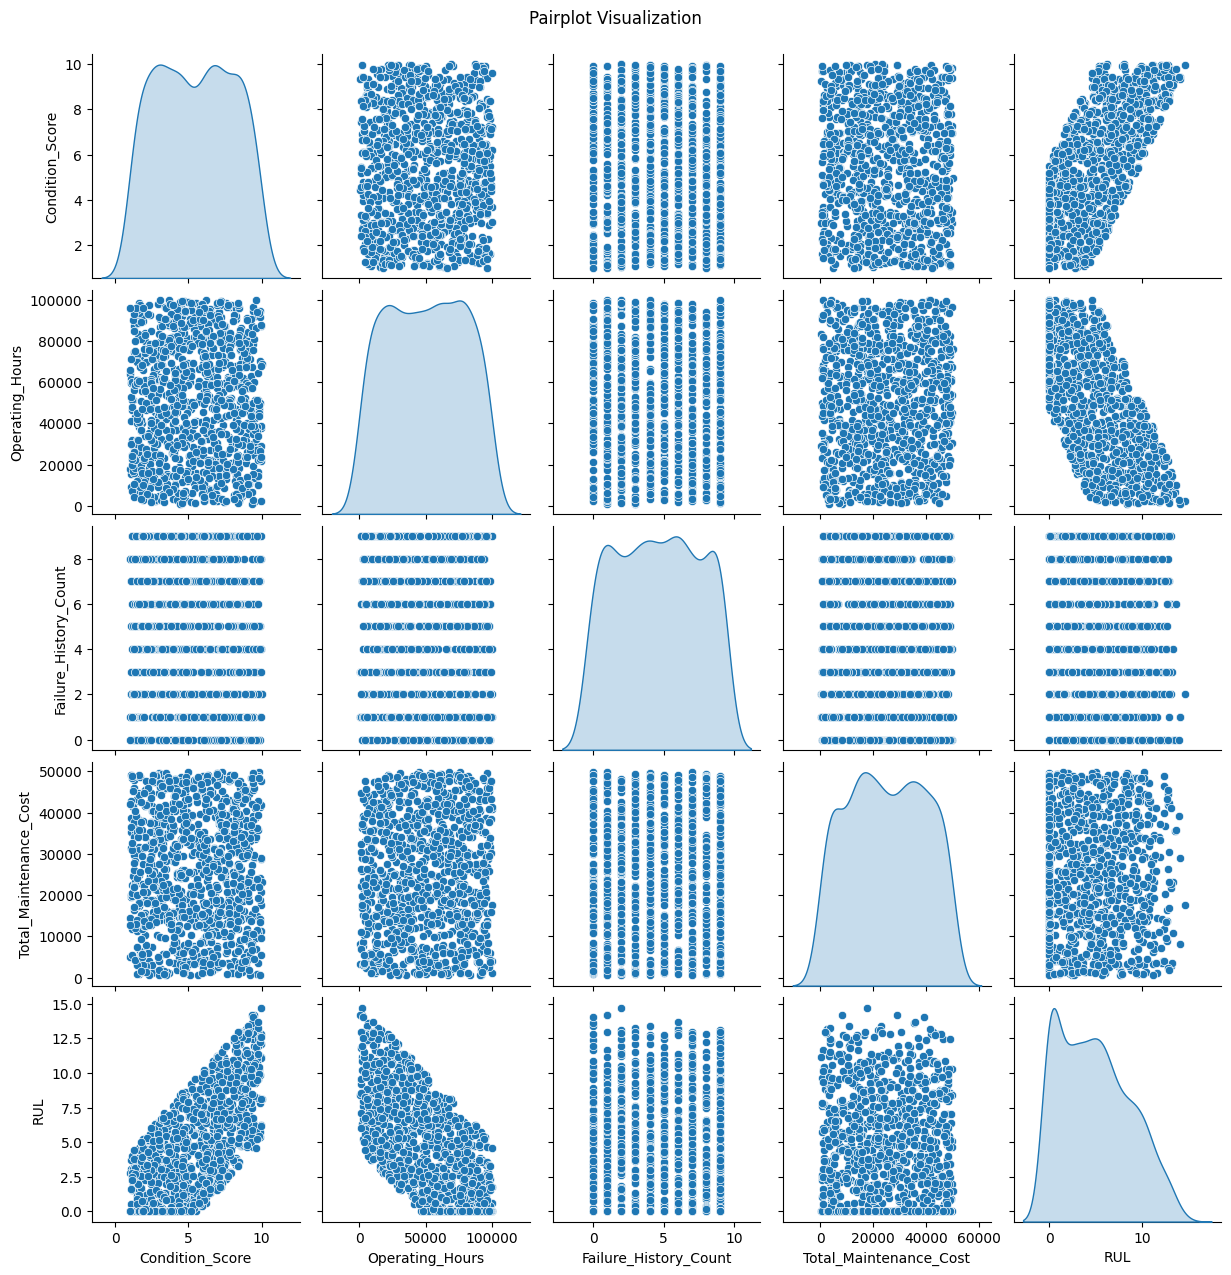

In [13]:
pairplot_features = [
    'Condition_Score',
    'Operating_Hours',
    'Failure_History_Count',
    'Total_Maintenance_Cost',
    'RUL'
]

sns.pairplot(
    df[pairplot_features],
    diag_kind='kde'
)

plt.suptitle(
    "Pairplot Visualization",
    y=1.02
)

plt.show()

In [14]:
df.to_csv(
    "../data/preprocessed_dataset.csv",
    index=False
)

print("Preprocessed Dataset Saved")

Preprocessed Dataset Saved
